In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
import cloudpickle as pickle

%config InlineBackend.figure_format = "retina"

In [2]:
@dataclass
class Model:
    # Input arrays
    t: np.ndarray = None  # observation times
    obs_x: np.ndarray = None  # locations of observation coordinates
    fault_x: np.ndarray = None  # fault locations

    # scalars
    n_t: int = 0  # number of time steps
    dt: int = 1  # duration of time step
    n_obs: int = 0  # number of observation coordinates
    n_faults: int = 0  # number of faults
    fault_dep: float = 0.0  # fault depths
    n_fault_patches: int = 1  # number of fault patches

    # 2D arrays
    obs_vels: np.ndarray = field(init=False)  # velocity (nt, nx)
    obs_poss: np.ndarray = field(init=False)  # position (nt, nx)
    block_vels: np.ndarray = field(init=False)  # block velocity history (nt, nf+1)
    block_disps: np.ndarray = field(init=False)  # block displacement history (nt, nf+1)
    fault_patch_partials: np.ndarray = field(init=False)
    obs_block_idx: np.ndarray = field(init=False)  # block index for each observation

    # 3D arrays
    fault_slip_rates: np.ndarray = field(
        init=False
    )  # fault slip rate history (nt, nf, nfp)
    fault_slip_cumulative: np.ndarray = field(
        init=False
    )  # fault slip history (nt, nf, nfp)

    @staticmethod
    def get_vel(s, x, fx, d):
        MIN_D = 1e-10
        if d < MIN_D:
            d = MIN_D
        vel = s / np.pi * np.arctan((x - fx) / d)
        return vel

    def get_fault_slip_rate_timeseries(
        self,
        fault_idx,
        patch_idx,
        eq_t,
        eq_slip,
        eq_afterslip_amp,
        eq_afterslip_dur,
        sse_t,
        sse_amp,
        sse_dur,
    ):
        """Generate fault slip rate time series with earthquakes, afterslip and slow slip events.

        Parameters:
        fault_idx: int - index of the fault
        patch_idx: int - index of the fault patch
        eq_t: np.ndarray - times of earthquakes
        eq_slip: np.ndarray - coseismic slip amplitudes
        eq_afterslip_amp: np.ndarray - afterslip amplitudes
        eq_afterslip_dur: np.ndarray - afterslip duration scales
        sse_t: np.ndarray - times of slow slip events
        sse_amp: np.ndarray - slow slip event amplitudes
        sse_dur: np.ndarray - slow slip event duration scales

        Updates:
        self.fault_slip_rates[:, fault_idx, patch_idx] with the computed time series
        """
        # Array to store fault slip rate history
        fault_slip_rate_timeseries = np.zeros(len(self.t))

        # 1. Add earthquake jumps
        eq_idx = np.zeros(eq_t.shape, dtype="int")
        for i in range(len(eq_t)):
            eq_idx[i] = np.argmin(np.abs(self.t - eq_t[i])).astype(int)
            fault_slip_rate_timeseries[eq_idx[i]] += eq_slip[i]

        # 2. Add afterslip
        for i in range(len(eq_t)):
            fault_slip_rate_timeseries[self.t > eq_t] = eq_afterslip_amp * np.exp(
                -eq_afterslip_dur * self.t[self.t > eq_t] - eq_t
            )

        # 3. Add slow slip events
        sse_idx = np.zeros(sse_t.shape, dtype="int")
        for i in range(len(sse_t)):
            sse_idx[i] = np.argmin(np.abs(self.t - sse_t[i])).astype(
                int
            )  # currently unused
            fault_slip_rate_timeseries += sse_amp[i] * np.exp(
                -((self.t - sse_t[i]) ** 2) / (2 * sse_dur[i] ** 2)
            )

        # Store the result directly in the model's fault_slip_rates array
        self.fault_slip_rates[:, fault_idx, patch_idx] = fault_slip_rate_timeseries

    def get_fault_slip_cumulative(self):
        # For each fault and patch, calculate cumulative slip
        for i in range(self.n_faults):
            for j in range(self.n_fault_patches):
                self.fault_slip_cumulative[:, i, j] = (
                    np.cumsum(self.fault_slip_rates[:, i, j]) * self.dt
                )

    def __post_init__(self):
        """Initialize arrays right after the object is created"""
        # Sort observation and fault locations in ascending order
        if self.obs_x is not None:
            self.obs_x = np.sort(self.obs_x)
        if self.fault_x is not None:
            self.fault_x = np.sort(self.fault_x)

        # Calculate dimensions from input arrays
        if self.t is not None:
            self.n_t = len(self.t)
        if self.obs_x is not None:
            self.n_obs = len(self.obs_x)
        if self.fault_x is not None:
            self.n_faults = len(self.fault_x)

        # Calculate time step
        if self.dt is not None:
            self.dt = self.t[1] - self.t[0]

        # Initialize empty arrays if input arrays were None
        if self.t is None and self.n_t > 0:
            self.t = np.zeros(self.n_t)
        if self.obs_x is None and self.n_obs > 0:
            self.obs_x = np.zeros(self.n_obs)
        if self.fault_x is None and self.n_faults > 0:
            self.fault_x = np.zeros(self.n_faults)

        # Initialze locking depths
        self.fault_patch_dep = np.zeros((self.n_faults, self.n_fault_patches + 1))
        for i in range(self.n_faults):
            self.fault_patch_dep[i, :] = np.linspace(
                0, self.fault_dep, self.n_fault_patches + 1
            )

        # Initialize 2D arrays
        self.fault_patch_partials = np.zeros(
            (self.n_obs, self.n_faults, self.n_fault_patches)
        )  # fault slip to surface displacments
        self.obs_vels = np.zeros(
            (self.n_t, self.n_obs)
        )  # velocity time series at observations
        self.obs_poss = np.zeros(
            (self.n_t, self.n_obs)
        )  # position time series at observations
        self.fault_slip_rates = np.zeros(
            (self.n_t, self.n_faults, self.n_fault_patches)
        )
        self.fault_slip_cumulative = np.zeros(
            (self.n_t, self.n_faults, self.n_fault_patches)
        )
        self.block_vels = np.zeros(
            (self.n_t, self.n_faults + 1)
        )  # block motion velocities
        self.block_disps = np.zeros(
            (self.n_t, self.n_faults + 1)
        )  # block motion displacements

        # Create slip to observed velocity partials for each patch
        for i in range(self.n_faults):
            for j in range(self.n_fault_patches):
                # velocity kernel calcuation
                v_upper = self.get_vel(
                    1, self.obs_x, self.fault_x[i], self.fault_patch_dep[i, j]
                )
                v_lower = self.get_vel(
                    1, self.obs_x, self.fault_x[i], self.fault_patch_dep[i, j + 1]
                )
                self.fault_patch_partials[:, i, j] = v_lower - v_upper

        # Assign observations to blocks
        self.obs_block_idx = np.searchsorted(self.fault_x, self.obs_x, side="right")

In [10]:
# Functions
# TODO: get_modes(model)
# TODO: Should every time series thing end in _ts?  Feels redundant
# TODO: Rescale to days, meters, km and all that
# TODO: Push time series generation to class

In [4]:
# Initialize model
model = Model(
    t=np.linspace(0, 1, 300),
    obs_x=np.linspace(-50, 50, 50),
    fault_x=np.array([0]),
    fault_dep=20,
    n_fault_patches=2,
)

# Generate patch 1 time series
model.get_fault_slip_rate_timeseries(
    fault_idx=0,
    patch_idx=0,
    eq_t=np.array([0.5]),
    eq_slip=np.array([25.0]),
    eq_afterslip_amp=np.array([0]),
    eq_afterslip_dur=np.array([0]),
    sse_t=np.array([0.35]),
    sse_amp=np.array([3.00]),
    sse_dur=np.array([0.02]),
)


# Generate patch 2 time series
model.get_fault_slip_rate_timeseries(
    fault_idx=0,
    patch_idx=1,
    eq_t=np.array([0.5]),
    eq_slip=np.array([0.0]),
    eq_afterslip_amp=np.array([200]),
    eq_afterslip_dur=np.array([8.0]),
    sse_t=np.array([0.25]),
    sse_amp=np.array([1.00]),
    sse_dur=np.array([0.03]),
)

# Get cumulative slip for all patches
model.get_fault_slip_cumulative()

# Plot fault time series (devaition from fully locked)

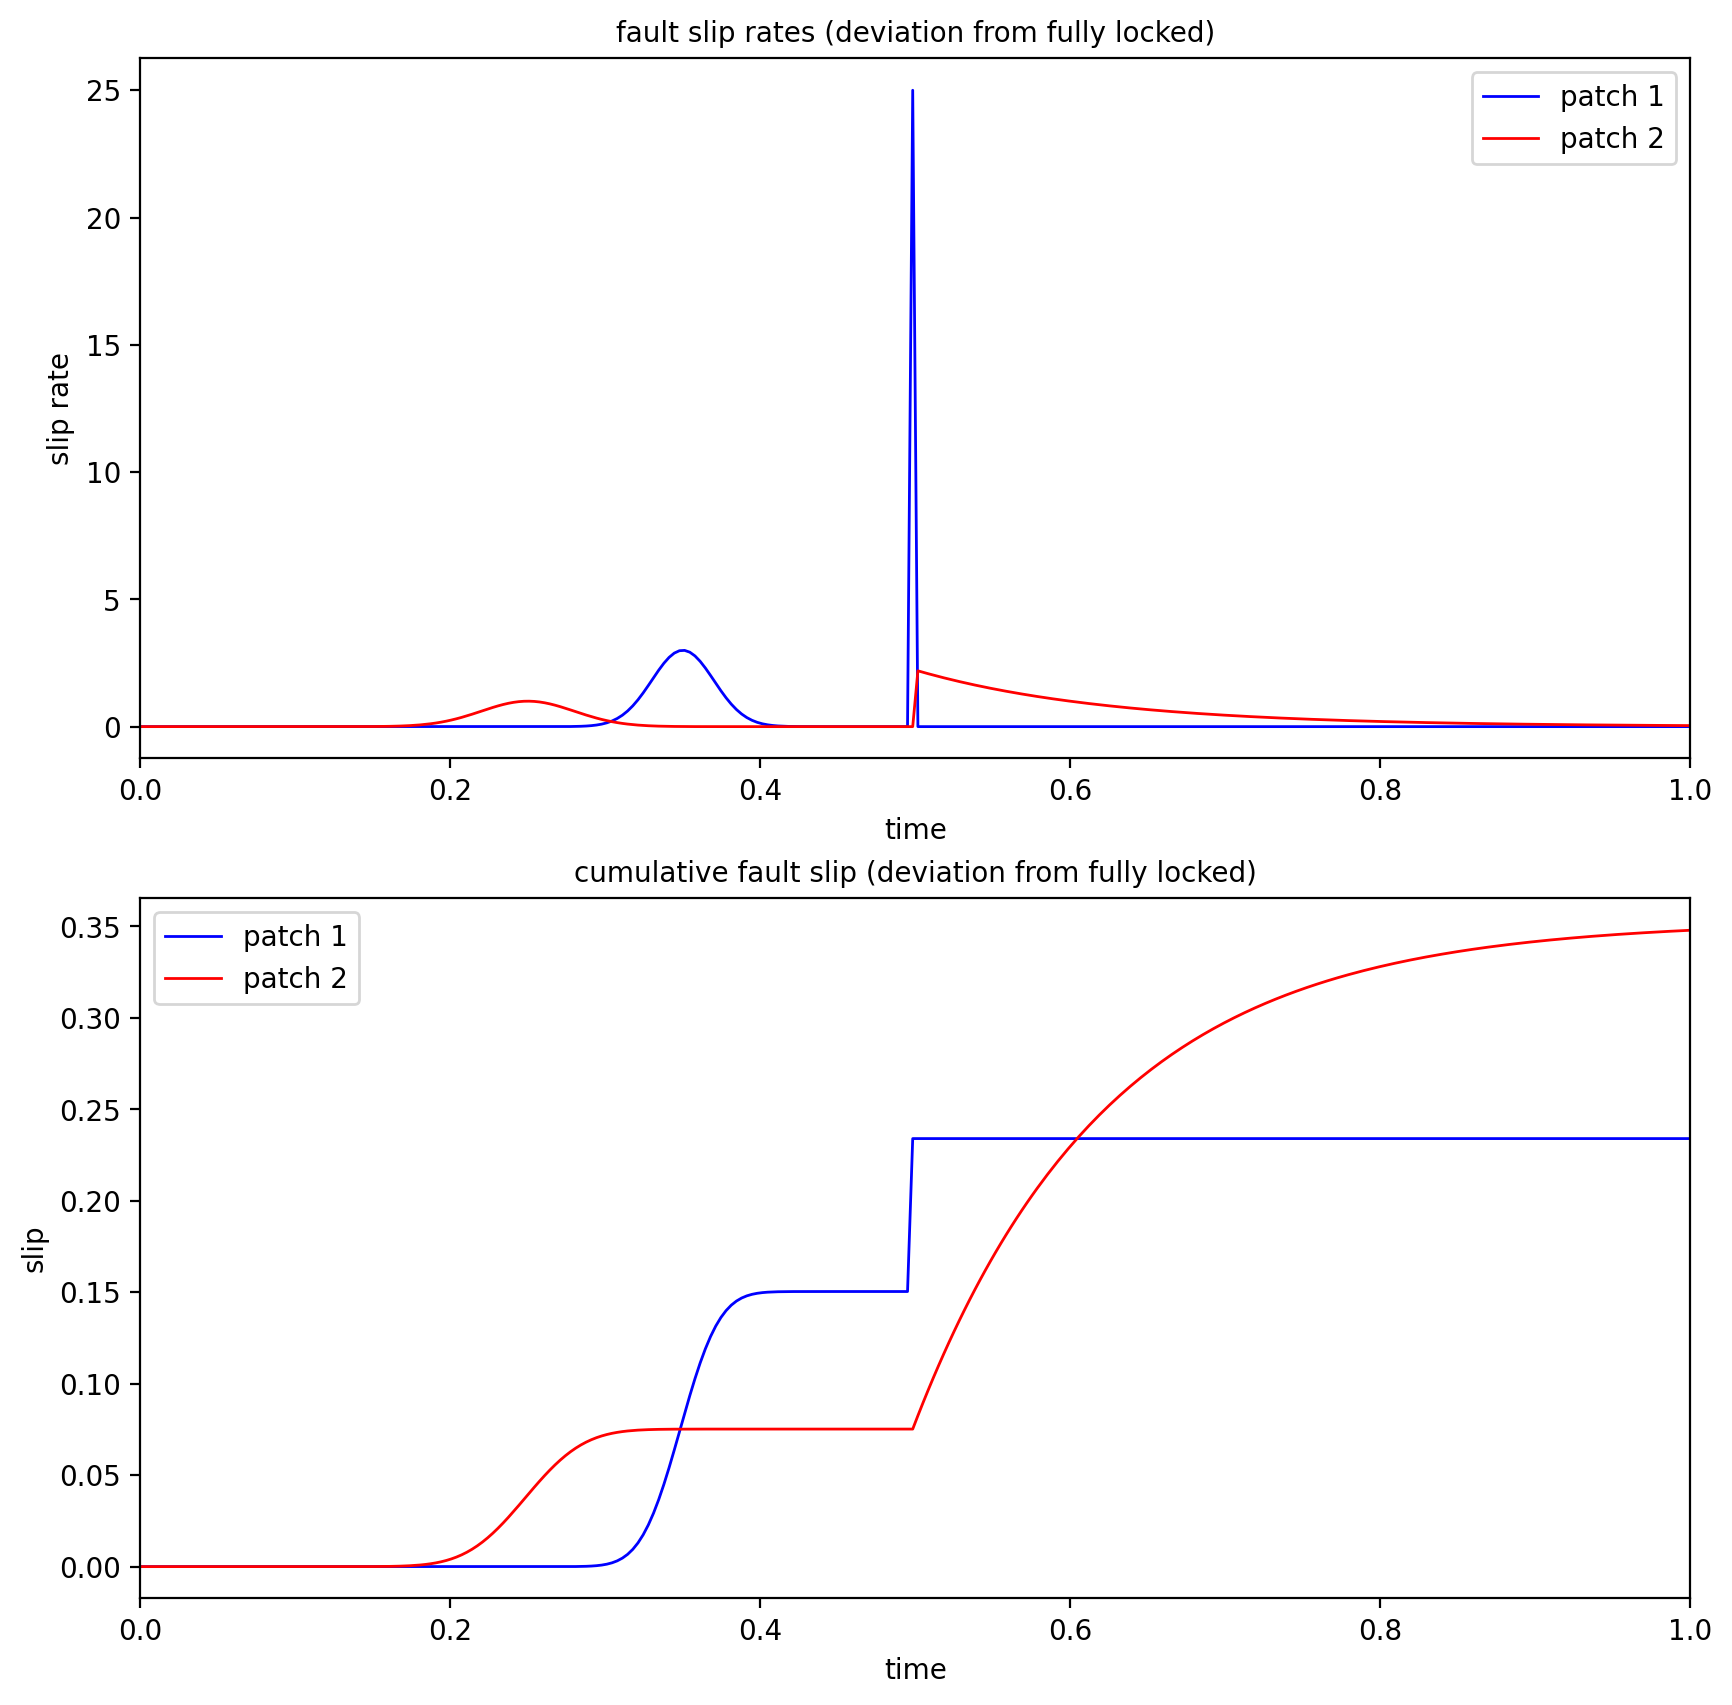

In [5]:
# Plot slip rates
linewidth = 1.0
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.plot(
    model.t, model.fault_slip_rates[:, 0, 0], "-b", label="patch 1", linewidth=linewidth
)
plt.plot(
    model.t, model.fault_slip_rates[:, 0, 1], "-r", label="patch 2", linewidth=linewidth
)
plt.legend()
plt.xlim([model.t.min(), model.t.max()])
plt.title("fault slip rates (deviation from fully locked)", fontsize=10)
plt.xlabel("time")
plt.ylabel("slip rate")

# Plot cumulative slip
plt.subplot(2, 1, 2)
plt.plot(
    model.t,
    model.fault_slip_cumulative[:, 0, 0],
    "-b",
    label="patch 1",
    linewidth=linewidth,
)
plt.plot(
    model.t,
    model.fault_slip_cumulative[:, 0, 1],
    "-r",
    label="patch 2",
    linewidth=linewidth,
)
plt.legend()
plt.xlim([model.t.min(), model.t.max()])
plt.title("cumulative fault slip (deviation from fully locked)", fontsize=10)
plt.xlabel("time")
plt.ylabel("slip")
plt.show()

# Build linear operator to go from model parameters to position time series

In [6]:
# Calculate block rates from fault slip rates
model.fault_slip_rates_block_diff = 1.0 * np.ones(
    (model.n_faults, model.n_t)
)  # TODO: This needs a better name
model.block_vels = np.cumsum(model.fault_slip_rates_block_diff, axis=0)
model.block_vels = np.concatenate((np.zeros((1, model.n_t)), model.block_vels))
model.block_vels = model.block_vels - (np.max(model.block_vels / 2.0))

# Generate forward time series
# Assemble linear operator (model -> data)
linear_operator = np.zeros(
    (
        model.n_obs,  # Number of observation locations
        model.n_faults
        + 1  # Number of blocks
        + model.n_faults * model.n_fault_patches,  # Total number of fault patches
    )
)

# Insert elastic partials into the right side of the linear operator
for i in range(model.n_faults):
    start_idx = model.n_faults + 1 + i * model.n_fault_patches
    linear_operator[:, start_idx : start_idx + model.n_fault_patches] = (
        model.fault_patch_partials[:, i, :]
    )

# Insert block motion partials into the left side of the linear operator
for i in range(model.n_faults + 1):
    current_idx = np.where(model.obs_block_idx == i)[0]
    linear_operator[current_idx, i] = 1

obs_v_mat = np.zeros((model.n_obs, model.n_t))
for i in range(model.n_t):
    # Initialize state vector
    true_state = np.zeros(model.n_faults + 1 + model.n_faults * model.n_fault_patches)

    # # Insert block motion rates
    for j in range(model.n_faults + 1):
        # true_state[j] = model.block_vels[i, j]
        true_state[j] = model.block_vels[j, i]

    # Insert fault slip rates
    for j in range(model.n_faults):
        start_idx = model.n_faults + 1 + j * model.n_fault_patches
        true_state[start_idx : start_idx + model.n_fault_patches] = (
            -model.fault_slip_rates[i, j, :]
            + model.fault_slip_rates_block_diff[
                j, i
            ]  # BUG: This "+1" needs to be generalized
        )

    # Calculate observed velocities
    obs_v_mat[:, i] = linear_operator @ true_state

# Convert observed velocities to observed positions
obs_p_mat = np.cumsum(obs_v_mat, axis=1) * (model.t[1] - model.t[0])

# Subtract out first position measurement so that all start at zero
obs_p_mat -= obs_p_mat[:, 0:1]  # Note strange indexing to prevent 1D array

# Add synthetic noise

# Plot station velocities and cumulative position time series

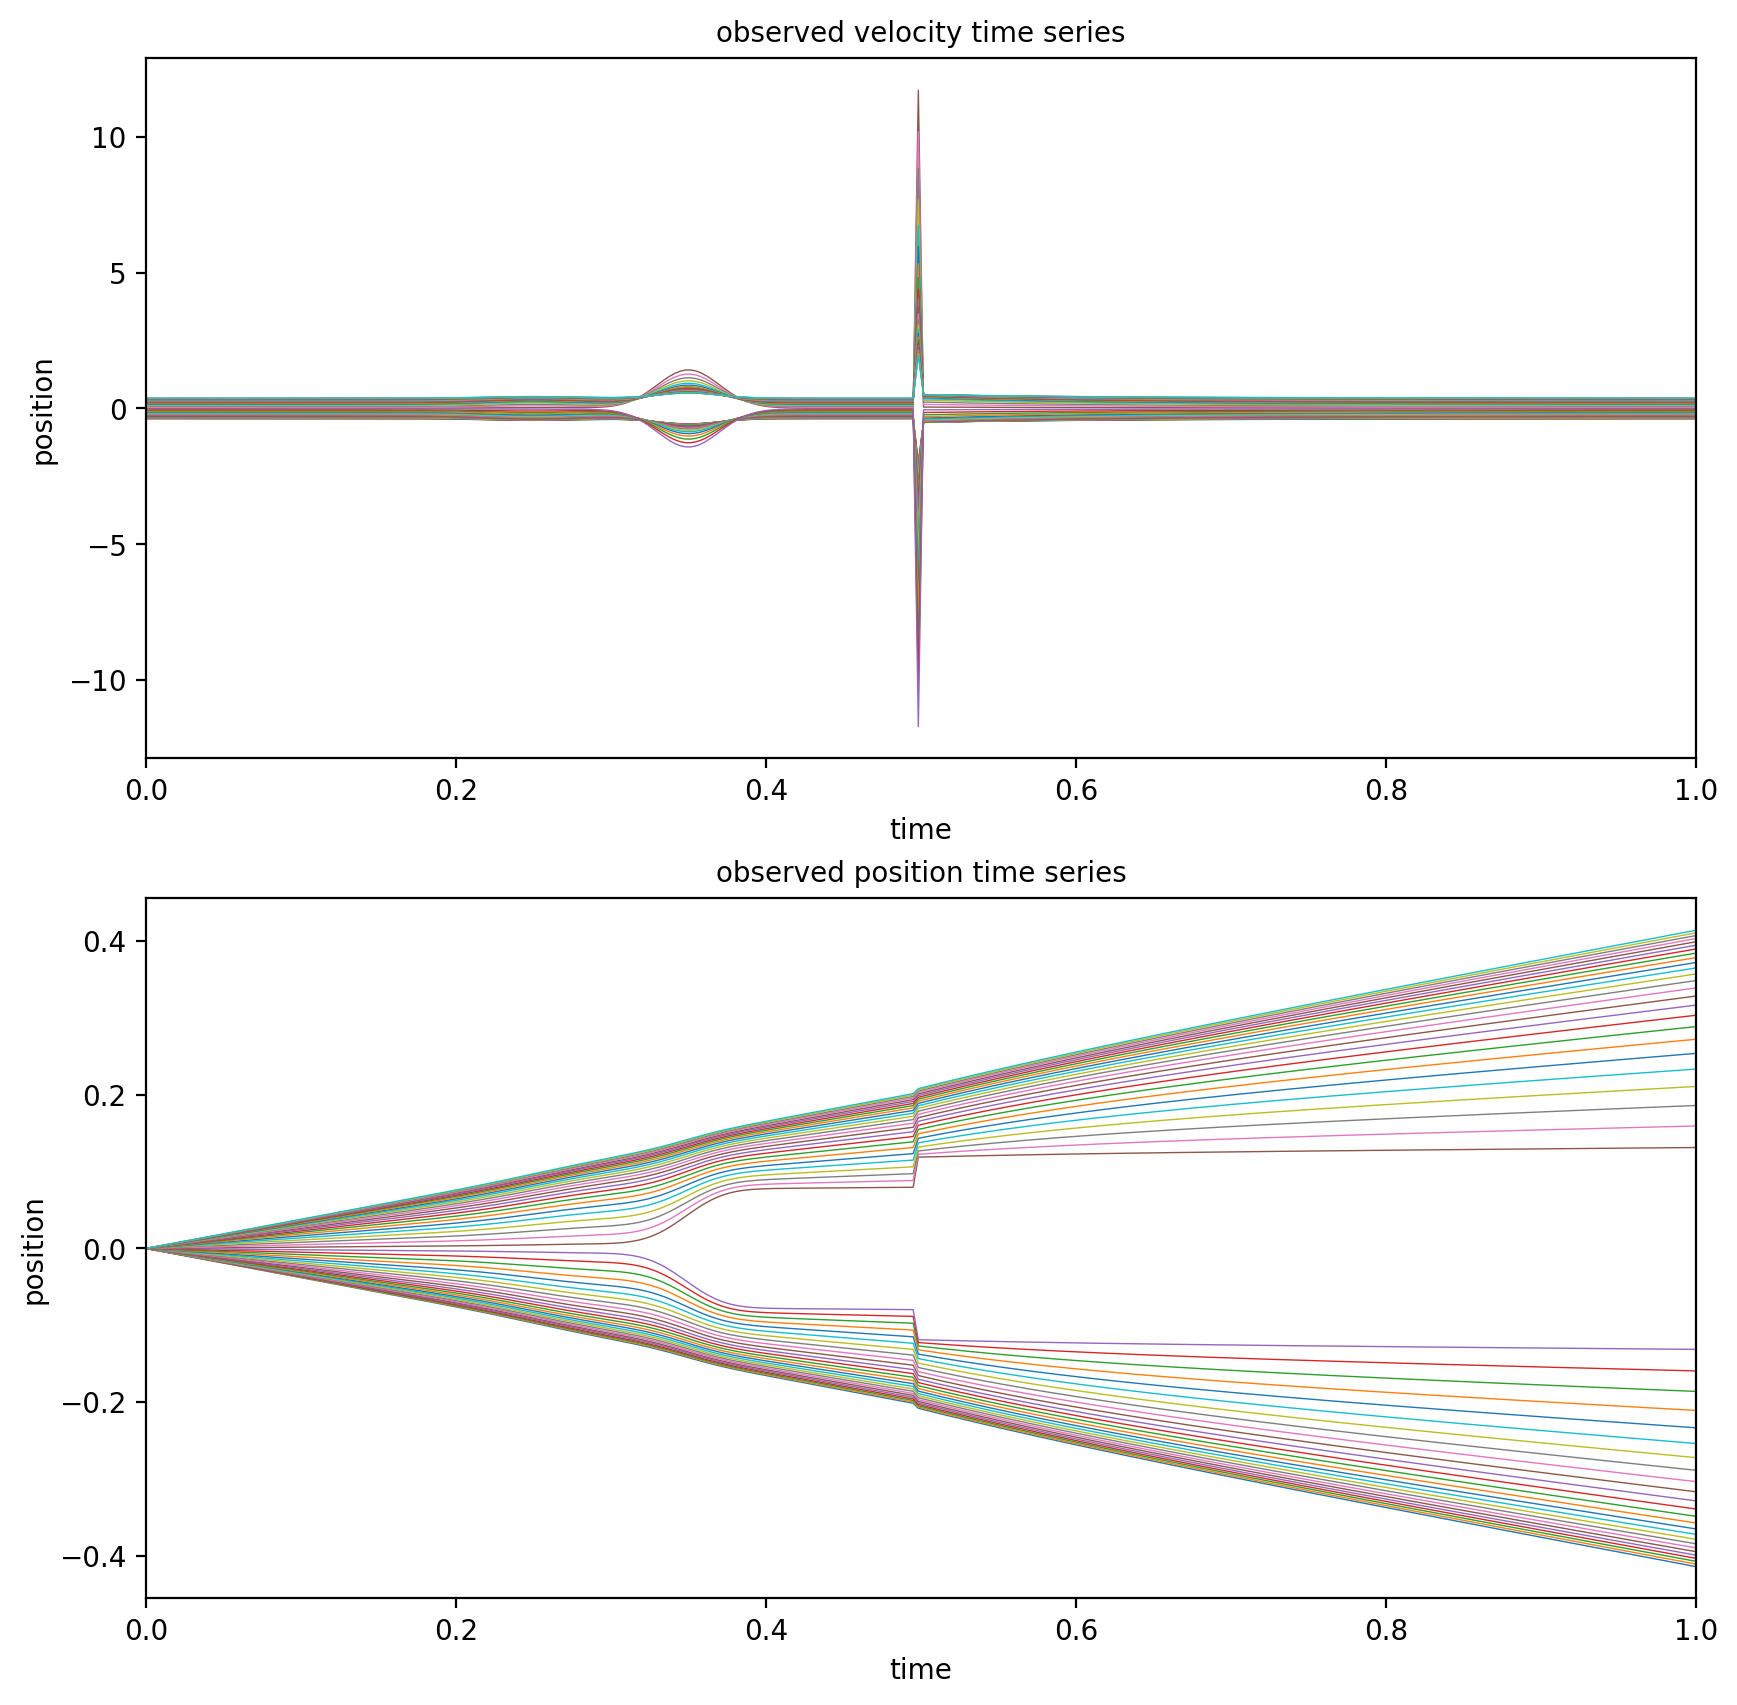

In [7]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.plot(model.t, obs_v_mat.T, linewidth=0.5)
plt.xlim([model.t.min(), model.t.max()])
plt.title("observed velocity time series", fontsize=10)
plt.xlabel("time")
plt.ylabel("position")

plt.subplot(2, 1, 2)
plt.plot(model.t, obs_p_mat.T, linewidth=0.5)
plt.xlim([model.t.min(), model.t.max()])
plt.title("observed position time series", fontsize=10)
plt.xlabel("time")
plt.ylabel("position")
plt.show()

# Plot total velocities and cumulative displacements

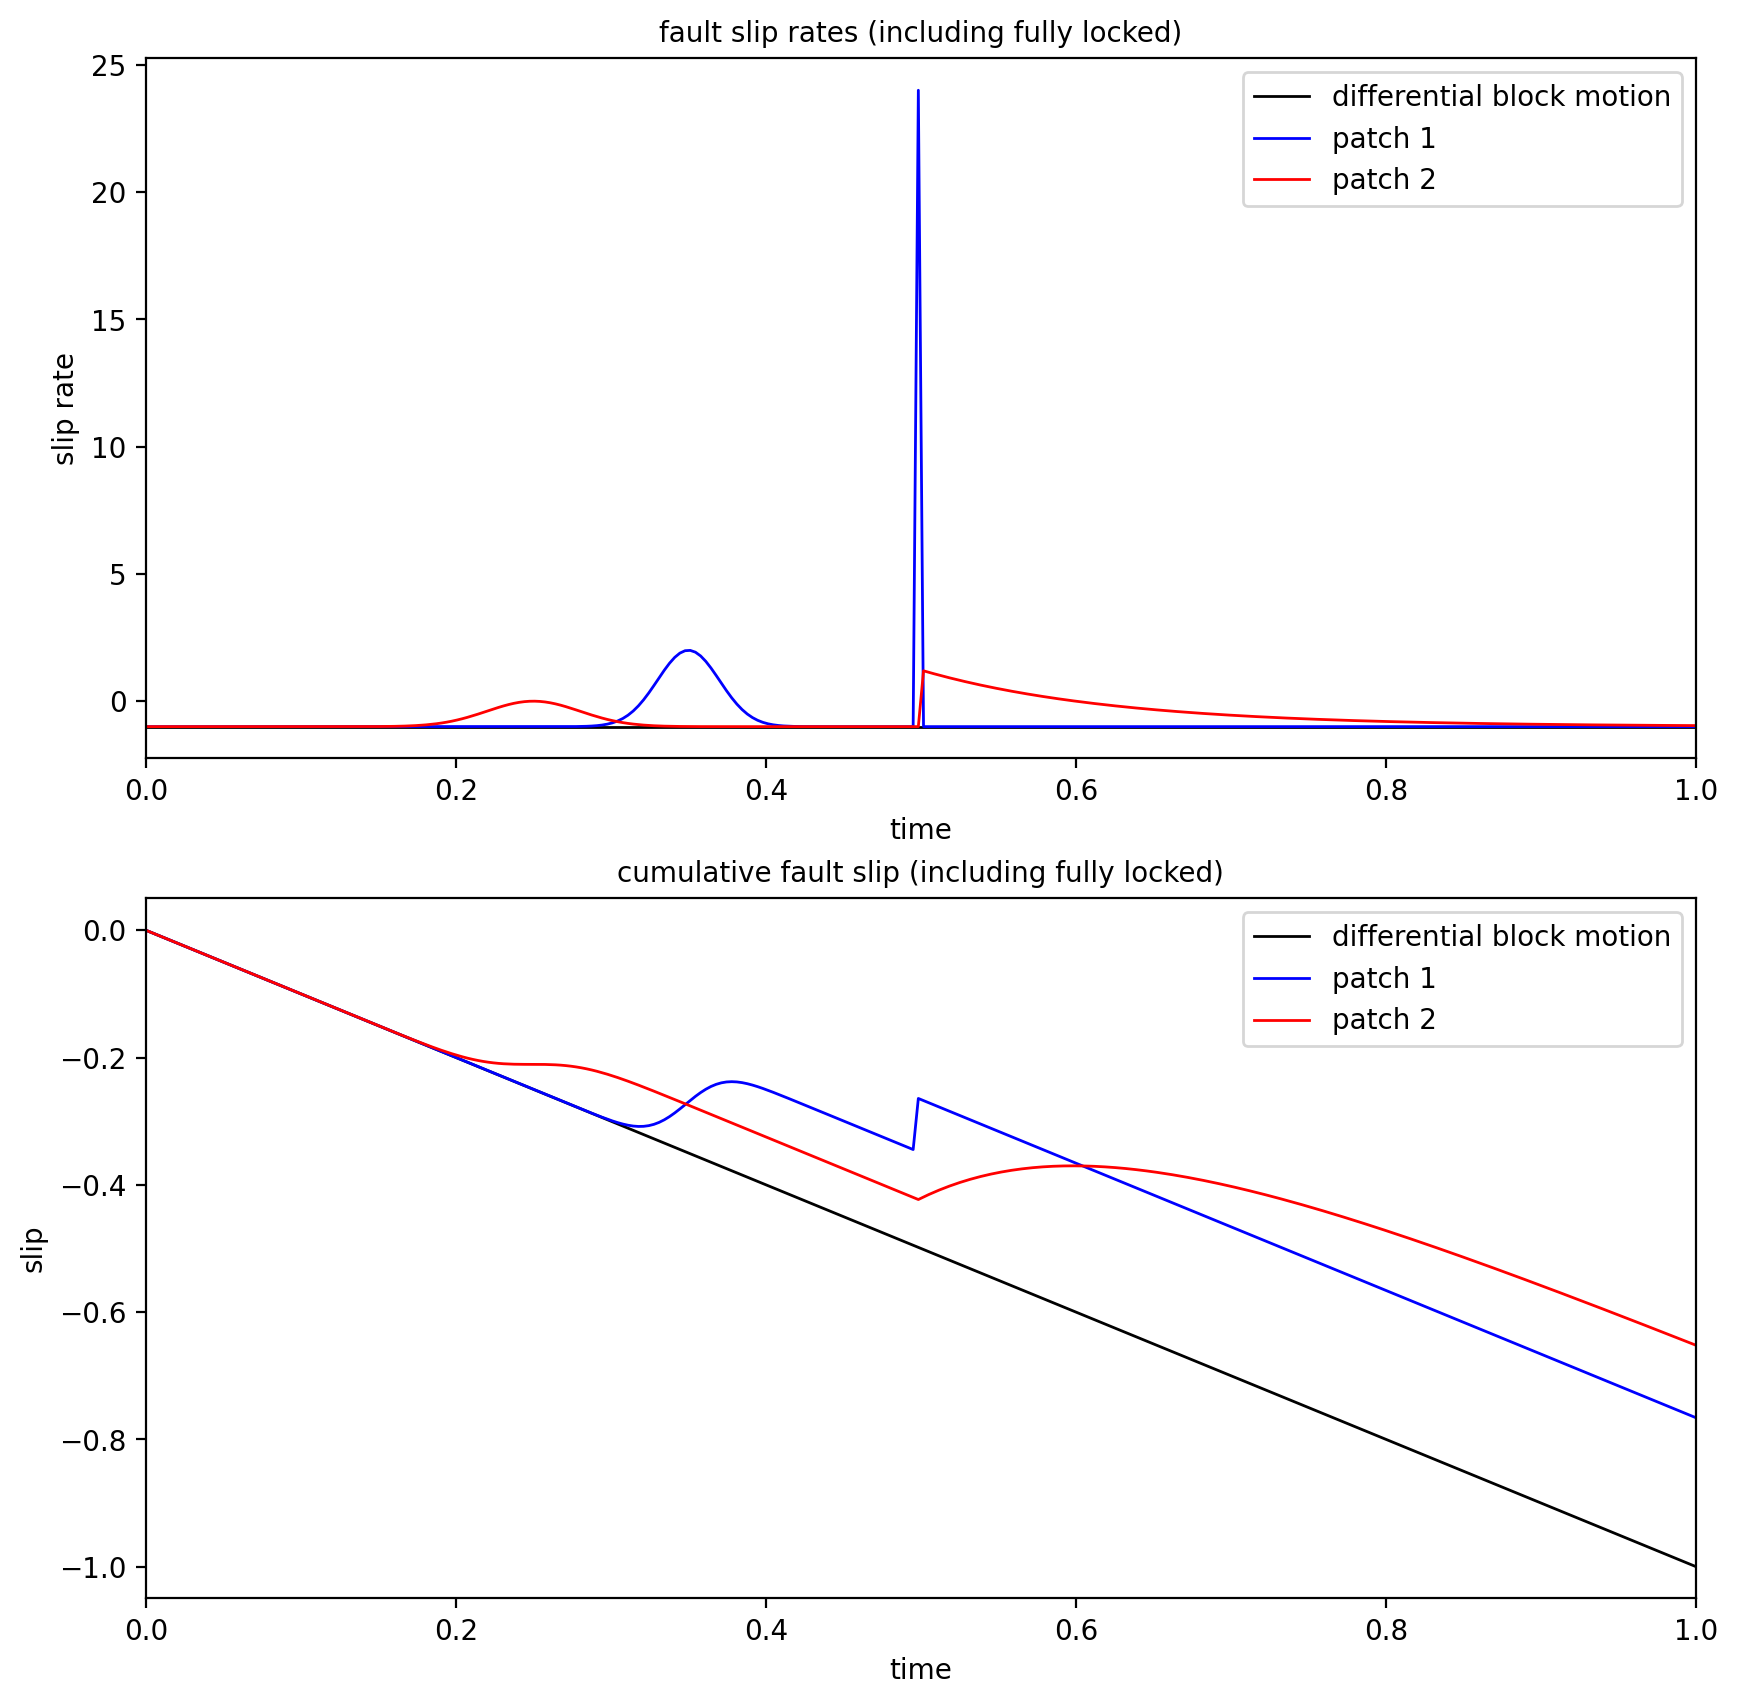

In [ ]:
# Something related to block motion and fault slip rates
# TODO: This needs better names
# TODO: This needs an explanation for a negative sign
# TODO: Push to function
diff_block_slip_cumulative = np.cumsum(np.squeeze(model.fault_slip_rates_block_diff))
diff_block_slip_cumulative -= diff_block_slip_cumulative[0]
diff_block_slip_cumulative *= model.dt


# Plot slip rates
linewidth = 1.0
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.plot(
    model.t,
    -np.squeeze(model.fault_slip_rates_block_diff),
    "-k",
    label="differential block motion",
    linewidth=linewidth,
)
plt.plot(
    model.t,
    model.fault_slip_rates[:, 0, 0] - np.squeeze(model.fault_slip_rates_block_diff),
    "-b",
    label="patch 1",
    linewidth=linewidth,
)
plt.plot(
    model.t,
    model.fault_slip_rates[:, 0, 1] - np.squeeze(model.fault_slip_rates_block_diff),
    "-r",
    label="patch 2",
    linewidth=linewidth,
)
plt.legend()
plt.xlim([model.t.min(), model.t.max()])
plt.title("fault slip rates (including fully locked)", fontsize=10)
plt.xlabel("time")
plt.ylabel("slip rate")

# Plot cumulative slip
plt.subplot(2, 1, 2)
plt.plot(
    model.t,
    -diff_block_slip_cumulative,
    "-k",
    label="differential block motion",
    linewidth=linewidth,
)
plt.plot(
    model.t,
    model.fault_slip_cumulative[:, 0, 0] - diff_block_slip_cumulative,
    "-b",
    label="patch 1",
    linewidth=linewidth,
)
plt.plot(
    model.t,
    model.fault_slip_cumulative[:, 0, 1] - diff_block_slip_cumulative,
    "-r",
    label="patch 2",
    linewidth=linewidth,
)
plt.legend()
plt.xlim([model.t.min(), model.t.max()])
plt.title("cumulative fault slip (including fully locked)", fontsize=10)
plt.xlabel("time")
plt.ylabel("slip")
plt.show()

# Save model as pickle file

In [9]:
# Save model instance as cloudpickle
filename_pickle = "forward_model_2d_001.pkl"
with open(filename_pickle, "wb") as f:
    pickle.dump(model, f)